In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from tdamapper.learn import MapperAlgorithm
from tdamapper.cover import CubicalCover

In [2]:
from src.static_tda import extract_structure_for_mapper, betti_from_graph, plot_graph

In [3]:
df = pd.read_csv("pheme_dataset.csv")

In [4]:
df.head(3)

,event,label,thread_id,is_source,tweet_id,user_id,screen_name,created_at,created_at_ts,text,in_reply_to_status_id,in_reply_to_user_id,retweet_count,favorite_count,lang
0,charliehebdo,non-rumour,552784600502915072,True,552784600502915072,331658004,BBCDanielS,2015-01-07 11:11:33+00:00,1.420629e+09,Charlie Hebdo became well known for publishing...,NaN,NaN,202,41,en
1,charliehebdo,non-rumour,552784600502915072,False,552785249420447745,18370911,robbylevy,2015-01-07 11:14:08+00:00,1.420629e+09,"Now 10 dead in a shooting there today RT ""@BBC...",5.527846e+17,331658004.0,0,0,en
2,charliehebdo,non-rumour,552784600502915072,False,552786761534144512,2806109387,ModerateInAll,2015-01-07 11:20:08+00:00,1.420630e+09,@BBCDanielS @BBCWorld I'm guessing this is bei...,5.527846e+17,331658004.0,0,0,en


### Preprocessing

In [5]:
for c in ["tweet_id", "thread_id", "user_id", "in_reply_to_status_id", "in_reply_to_user_id"]:
    df[c] = df[c].astype("Int64").astype("string")

df = df.sort_values("created_at_ts").reset_index(drop=True).copy()

In [6]:
df.head(3)

,event,label,thread_id,is_source,tweet_id,user_id,screen_name,created_at,created_at_ts,text,in_reply_to_status_id,in_reply_to_user_id,retweet_count,favorite_count,lang
0,ferguson,non-rumour,498235547685756928,True,498235547685756928,1539100118,annaxsweat,2014-08-09 22:33:06+00:00,1.407624e+09,Black teenage boys are not men. They are child...,<NA>,<NA>,236,124,en
1,ferguson,non-rumour,498235547685756928,False,498235547685756928,1539100118,annaxsweat,2014-08-09 22:33:06+00:00,1.407624e+09,Black teenage boys are not men. They are child...,<NA>,<NA>,233,124,en
2,ferguson,non-rumour,498235547685756928,False,498243332204949504,587926686,NavyDad0007,2014-08-09 23:04:01+00:00,1.407625e+09,@annaxsweat @NeoSoulPol Same thing when #Trayv...,498235547685756928,1539100118,1,0,en


### Extract structure for mapper for one thread

In [7]:
thread_id = df["thread_id"].iloc[5]
thread_df = (
    df[df["thread_id"] == thread_id]
    .copy()
    .sort_values("created_at_ts")
    .reset_index(drop=True)
)

In [8]:
X, g = extract_structure_for_mapper(thread_df)

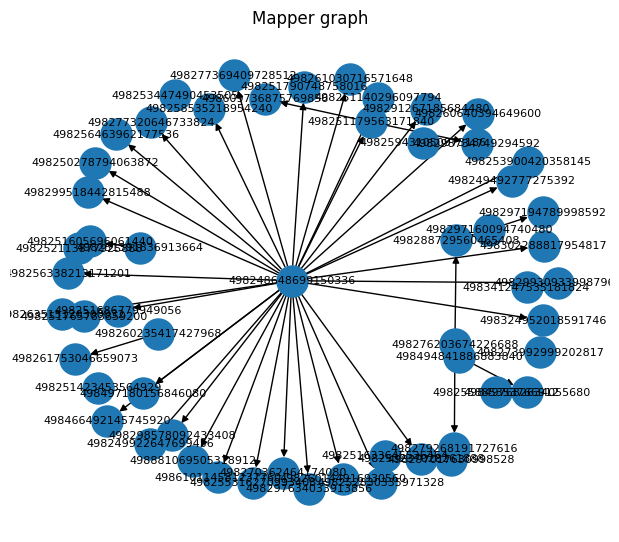

In [9]:
plot_graph(g)

In [10]:
X

array([[0.        , 1.        , 0.        , 0.        , 0.        ,
        0.5       , 1.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.5       , 1.        ],
       [0.00133306, 0.        , 1.        , 0.5       , 0.01785714,
        0.25      , 0.        ],
       [0.00201617, 0.        , 1.        , 0.5       , 0.01785714,
        0.25      , 0.        ],
       [0.0025799 , 0.        , 1.        , 0.5       , 0.01785714,
        0.25      , 0.        ],
       [0.00393949, 0.        , 1.        , 0.5       , 0.01785714,
        1.        , 0.        ],
       [0.00399918, 0.        , 1.        , 0.5       , 0.01785714,
        0.25      , 0.0625    ],
       [0.00433742, 0.        , 1.        , 0.        , 0.        ,
        0.5       , 0.03125   ],
       [0.00439047, 0.        , 1.        , 0.        , 0.        ,
        0.25      , 0.        ],
       [0.00467566, 0.        , 1.        , 0.        , 0.125     ,
        1.        , 0.0

In [11]:
X.shape

(57, 7)

### Mapper on one thread

#### Initial test with given parameters

In [12]:
# https://tda-mapper.readthedocs.io/en/main/quickstart.html#how-to-use
# parameters from the tutorial

N_INTERVALS = 10
OVERLAP_FRAC = 0.3

lens = X[:, [0, 3]] # time + reply depth -> time as a feature, Mapper does not create filtrations for PH

cover = CubicalCover(n_intervals = N_INTERVALS, overlap_frac = OVERLAP_FRAC)
clusterer = DBSCAN()
graph = MapperAlgorithm(cover, clusterer).fit_transform(X, lens) 

G = nx.Graph(graph) # graph from mapper that organizes the tweets according to where they lie in the (time, depth) view 

In [13]:
d = betti_from_graph(G)

In [14]:
d

{'n_nodes_mapper': 3, 'n_edges_mapper': 0, 'h0_mapper': 3, 'h1_mapper': 0}

#### Hyperparameter tuning

In [15]:
pca = PCA(n_components=2)
lens = pca.fit_transform(X)

for i in [4, 6, 8]:
    for o in [0.1, 0.3, 0.5]:
        for eps in [0.3, 0.5, 0.8, 1.0]:
            clusterer = DBSCAN(eps=eps, min_samples=1)
            cover = CubicalCover(n_intervals=i, overlap_frac=o)

            graph = MapperAlgorithm(cover, clusterer).fit_transform(X, lens)
            G = nx.Graph(graph)
            d = betti_from_graph(G)

            print(
                f"n_intervals={i}, overlap={o}, eps={eps}, "
                f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, betti={d}"
            )

n_intervals=4, overlap=0.1, eps=0.3, nodes=18, edges=5, betti={'n_nodes_mapper': 18, 'n_edges_mapper': 5, 'h0_mapper': 14, 'h1_mapper': 1}
n_intervals=4, overlap=0.1, eps=0.5, nodes=13, edges=4, betti={'n_nodes_mapper': 13, 'n_edges_mapper': 4, 'h0_mapper': 10, 'h1_mapper': 1}
n_intervals=4, overlap=0.1, eps=0.8, nodes=8, edges=4, betti={'n_nodes_mapper': 8, 'n_edges_mapper': 4, 'h0_mapper': 5, 'h1_mapper': 1}
n_intervals=4, overlap=0.1, eps=1.0, nodes=7, edges=4, betti={'n_nodes_mapper': 7, 'n_edges_mapper': 4, 'h0_mapper': 4, 'h1_mapper': 1}
n_intervals=4, overlap=0.3, eps=0.3, nodes=16, edges=4, betti={'n_nodes_mapper': 16, 'n_edges_mapper': 4, 'h0_mapper': 12, 'h1_mapper': 0}
n_intervals=4, overlap=0.3, eps=0.5, nodes=9, edges=2, betti={'n_nodes_mapper': 9, 'n_edges_mapper': 2, 'h0_mapper': 7, 'h1_mapper': 0}
n_intervals=4, overlap=0.3, eps=0.8, nodes=5, edges=2, betti={'n_nodes_mapper': 5, 'n_edges_mapper': 2, 'h0_mapper': 3, 'h1_mapper': 0}
n_intervals=4, overlap=0.3, eps=1.0, no

In [16]:
# best parameters

clusterer = DBSCAN(eps = 0.5, min_samples = 1)
cover = CubicalCover(n_intervals = 6, overlap_frac = 0.3)

graph = MapperAlgorithm(cover, clusterer).fit_transform(X, lens)
best_G = nx.Graph(graph)
best_d = betti_from_graph(G)

print(d)

{'n_nodes_mapper': 7, 'n_edges_mapper': 3, 'h0_mapper': 4, 'h1_mapper': 0}


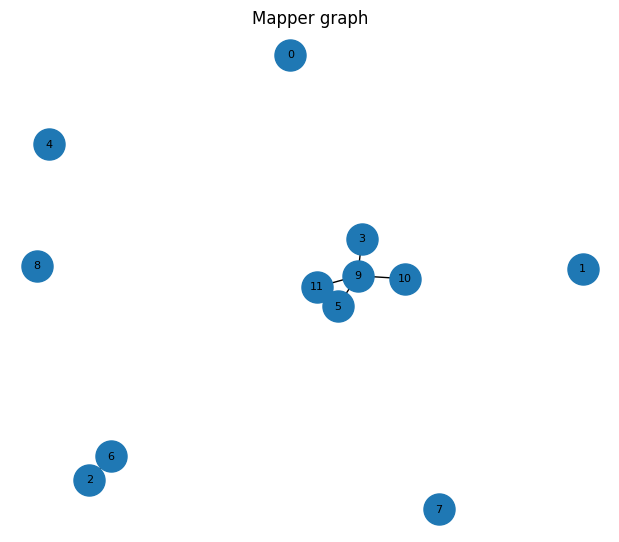

In [17]:
plot_graph(best_G)

### Mapper on all threads

In [18]:
all_mapper_features = []

for thread_id, thread_df in df.groupby("thread_id"):

    thread_df = (
        df[df["thread_id"] == thread_id]
        .copy()
        .sort_values("created_at_ts")
        .reset_index(drop=True)
    )
    
    X, G = extract_structure_for_mapper(thread_df)

    if len(X) < 2:
        G_mapper = nx.Graph()
    else:
        pca = PCA(n_components=2)
        lens = pca.fit_transform(X)
        
        clusterer = DBSCAN(eps = 0.5, min_samples = 1)
        cover = CubicalCover(n_intervals = 6, overlap_frac = 0.3) #best params

        graph = MapperAlgorithm(cover, clusterer).fit_transform(X, lens)
        G_mapper = nx.Graph(graph)
    feats = betti_from_graph(G_mapper)

    all_mapper_features.append({
        "thread_id": thread_df["thread_id"].iloc[0],
        "label": thread_df["label"].iloc[0],
        "event": thread_df["event"].iloc[0],
        "n_tweets": len(thread_df),
        **feats,
    })

mapper_features_df = pd.DataFrame(all_mapper_features)
mapper_features_df.head()

,thread_id,label,event,n_tweets,n_nodes_mapper,n_edges_mapper,h0_mapper,h1_mapper
0,498235547685756928,non-rumour,ferguson,15,8,1,7,0
1,498248415223246848,non-rumour,ferguson,27,8,4,5,1
2,498248648699150336,non-rumour,ferguson,57,12,6,7,1
3,498250100079341568,non-rumour,ferguson,5,4,0,4,0
4,498251940997136384,non-rumour,ferguson,9,5,1,4,0


### Analysis

In [19]:
mapper_df = mapper_features_df.copy()

print(mapper_df[["n_nodes_mapper", "n_edges_mapper", "h0_mapper", "h1_mapper"]].describe())

       n_nodes_mapper  n_edges_mapper    h0_mapper    h1_mapper
count     5802.000000     5802.000000  5802.000000  5802.000000
mean         7.163737        2.142365     5.395381     0.374009
std          4.857253        3.962164     2.738219     1.373174
min          0.000000        0.000000     0.000000     0.000000
25%          4.000000        0.000000     4.000000     0.000000
50%          6.000000        1.000000     5.000000     0.000000
75%          9.000000        2.000000     7.000000     0.000000
max         37.000000       49.000000    21.000000    23.000000


In [20]:
print("Fraction with h1 > 0:", (mapper_df["h1_mapper"] > 0).mean())
print("Fraction with no edges:", (mapper_df["n_edges_mapper"] == 0).mean())
print("Fraction with one component:", (mapper_df["h0_mapper"] == 1).mean())

Fraction with h1 > 0: 0.14426059979317477
Fraction with no edges: 0.44260599793174765
Fraction with one component: 0.0


In [21]:
mapper_df.groupby("label")[[
    "n_tweets",
    "n_nodes_mapper",
    "n_edges_mapper",
    "h0_mapper",
    "h1_mapper"
]].agg(["mean", "median", "std"])

n_tweets                   n_nodes_mapper                   \
                 mean median        std           mean median       std   
label                                                                     
non-rumour  18.742037   15.0  21.684561       7.383290    6.0  5.089364   
rumour      15.938134   13.0  16.425322       6.737323    6.0  4.340992   

           n_edges_mapper                 h0_mapper                   \
                     mean median      std      mean median       std   
label                                                                  
non-rumour       2.308877    1.0  4.16823  5.490339    5.0  2.832908   
rumour           1.818966    1.0  3.50620  5.210953    5.0  2.534815   

           h1_mapper                   
                mean median       std  
label                                  
non-rumour  0.415927    0.0  1.419046  
rumour      0.292596    0.0  1.275809

In [22]:
mapper_df.to_csv("mapper_df.csv")